In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("da_sales_transactions.csv")

df.head()

,Transaction_ID,Date,Customer_ID,Product_ID,Category,Units,Unit_Price,Discount_Pct,Channel,City,Return_Flag
0,T1,2025-01-24,C2,P2,Sports,5,539,15,Marketplace,Pune,1
1,T2,2025-12-15,C3,P3,Grocery,1,4228,5,Marketplace,Delhi,0
2,T3,2025-10-11,C4,P4,Books,2,2061,15,Offline,Chennai,0
3,T4,2025-04-24,C5,P5,Electronics,3,2164,0,Website,Chennai,0
4,T5,2025-06-25,C6,P6,Apparel,1,2341,0,Website,Kolkata,0


# Pearson and Spearman Correlation

In [2]:
pearson = df["Units"].corr(df["Unit_Price"], method="pearson")
spearman = df["Units"].corr(df["Unit_Price"], method="spearman")

print("Pearson Correlation:", pearson)
print("Spearman Correlation:", spearman)

Pearson Correlation: -0.0272861733358519
Spearman Correlation: -0.027390625483314873


                 Units  Unit_Price  Discount_Pct
Units         1.000000   -0.027286      0.058434
Unit_Price   -0.027286    1.000000     -0.063228
Discount_Pct  0.058434   -0.063228      1.000000


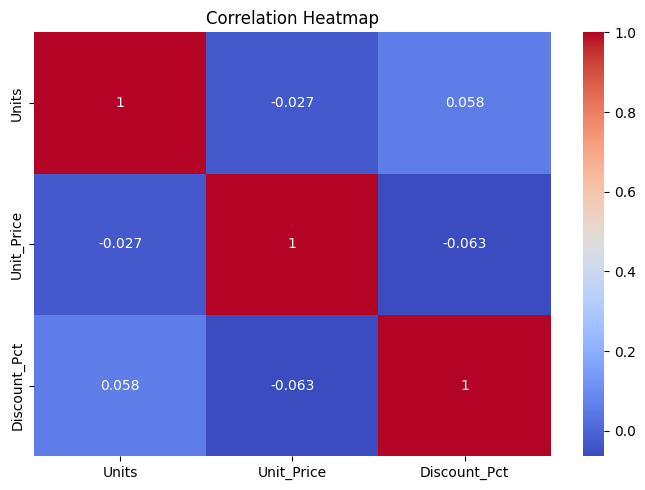

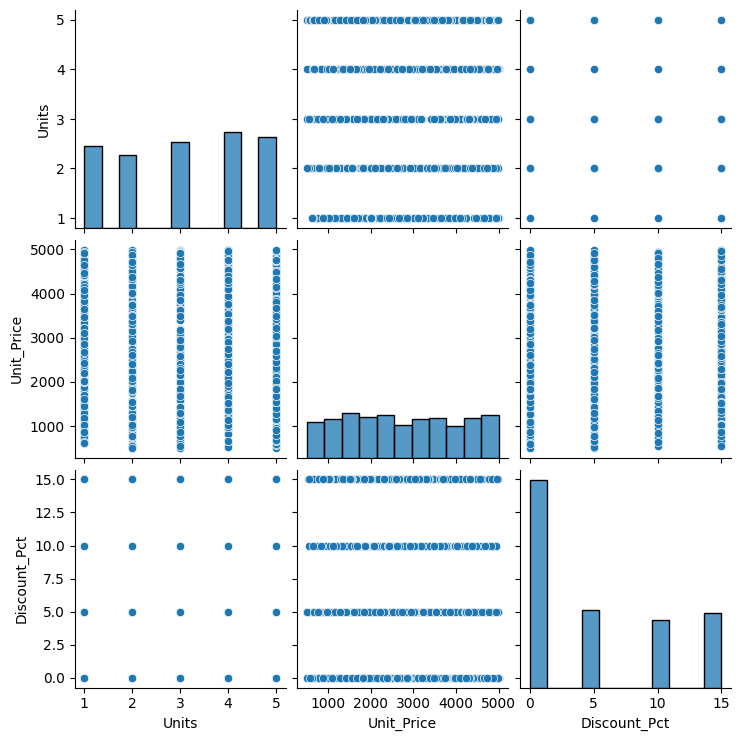

In [4]:
# 3. Correlation Matrix
corr = df[["Units", "Unit_Price", "Discount_Pct"]].corr()

print(corr)

# Heatmap:

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter Matrix

sns.pairplot(
    df[["Units", "Unit_Price", "Discount_Pct"]]
)

plt.show()

# Simple Linear Regression

We will predict Unit_Price from Units.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Units"]]
y = df["Unit_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [7]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 2830.2680641245565
Coefficient: -27.670329971733754


# Plot Regression Line

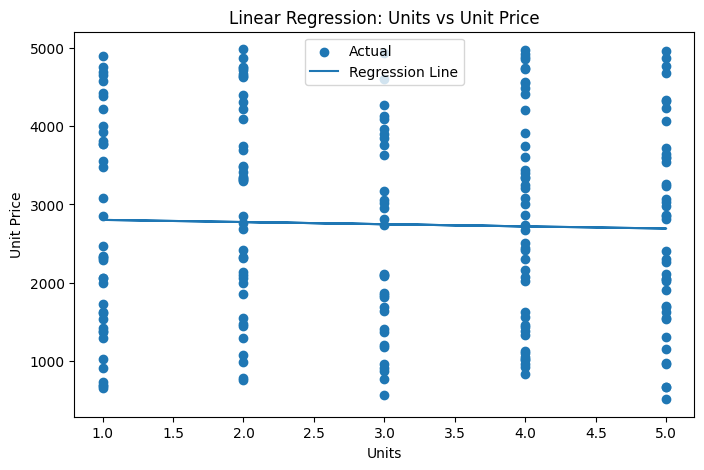

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Regression Line")

plt.xlabel("Units")
plt.ylabel("Unit Price")
plt.title("Linear Regression: Units vs Unit Price")
plt.legend()
plt.show()

In [9]:
# R², MAE and RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 8.707552333953039e-05
MAE: 1150.770164848728
RMSE: 1314.4462402437289


# Residual Plot

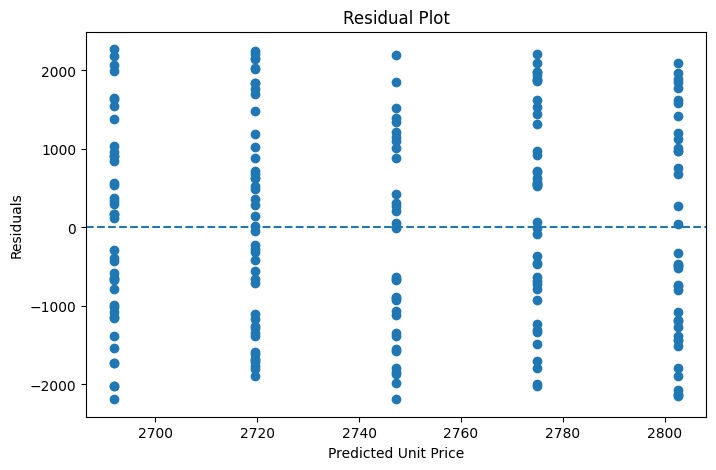

In [10]:
# Residual = Actual − Predicted.

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Unit Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# Conclusion

The analysis examined the relationship between Units and Unit Price using Pearson and Spearman correlation coefficients. A correlation matrix, heatmap, and scatter matrix were used to visualise relationships among the numerical variables. A simple linear regression model was then developed using Units to predict Unit Price. Model performance was evaluated using R², MAE, and RMSE. Finally, a residual plot was used to check whether the errors were randomly distributed around zero and to identify potential non-linearity, unequal variance, or outliers.
